In [127]:
import sionna.rt
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver, RadioMapSolver, Camera
import numpy as np
import matplotlib.pyplot as plt
import mitsuba as mi

In [128]:
scene = load_scene("scene/final_scene_windows.xml",merge_shapes=False)
scene.frequency = 40e9 #Hz
scene.synthetic_array = True
for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

elm__2         itu_marble
elm__5         itu_brick
elm__6         itu_brick
elm__7         itu_brick
elm__9         itu_metal
elm__10        itu_metal
elm__11        itu_metal
elm__12        itu_metal
elm__13        itu_metal
elm__14        itu_metal
elm__15        itu_metal
elm__17        itu_glass
elm__18        itu_glass
elm__19        itu_glass
elm__20        itu_glass
elm__21        itu_glass
elm__22        itu_glass
elm__23        itu_glass
elm__25        itu_wood
elm__26        itu_wood
elm__27        itu_wood
elm__28        itu_wood
elm__29        itu_wood
elm__30        itu_wood
elm__31        itu_wood
elm__32        itu_wood
elm__33        itu_wood
elm__34        itu_wood
elm__35        itu_wood
elm__36        itu_wood
elm__37        itu_wood
elm__38        itu_wood
elm__39        itu_wood
elm__40        itu_wood
elm__41        itu_wood
elm__42        itu_wood
elm__43        itu_wood
elm__44        itu_wood
elm__45        itu_wood
elm__46        itu_wood
elm__47        itu_wo

In [129]:
scene.preview()

In [130]:
# Configure antenna array
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V")

scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V")


In [131]:
#Create transmitter and receiver
tx = Transmitter(name="tx",
                 position=mi.Point3f(-7, 0, 1),
                 orientation=mi.Point3f(0, 0, 0))
nReceptor = 22
positions = ( (-6.5 , 4),   #1
              (-4   , 3),   #2
              (-2   , 3),   #3
              (0    , 3),   #4
              (1    , 1.2), #5
              (-2   , 1.2), #6
              (-6   , 1.2), #7
              (-4.5 , 1.2), #7b
              (-5.3 , -0.5),#8
              (-2.5 , 0.2), #9
              (0.5  , 0.5), #10
              (2.5  , 1),   #11
              (3    , -1),  #12
              (1    , -2),  #13
              (-2   , -2),  #14
              (-5.3 , -2.5),#15
              (-7   , -2.5),#16
              (-5.7 , -4),  #17
              (-4   , -4),  #17b
              (-2   , -4),  #18
              (1    , -4),  #19
              (3    , -4))  #20
for i in range(nReceptor):
    posx = positions[i][0]
    posy = positions[i][1]
    posz = 1
    rx = Receiver(name=f"rx_{i}",
                 position=[posx, posy, posz],
                 orientation=(0.0, 0.0, 0.0))
    scene.add(rx)

scene.add(tx)

In [135]:
#Compute propagation paths
solver  = PathSolver()
paths = solver(scene,max_depth=4, samples_per_src= int(1e6))

scene.preview(paths=paths)

In [133]:
#Compute Radio Map
rmSolver = RadioMapSolver()

rm = rmSolver(scene, cell_size=(.005, .005), samples_per_tx= 100000000)
scene.preview(radio_map=rm, clip_at=15., rm_vmin=-100.)

#Other way to compute it, less details
#rm = rmSolver(scene, max_depth=10, cell_size=[0.05, 0.05])
#scene.preview(radio_map=rm)

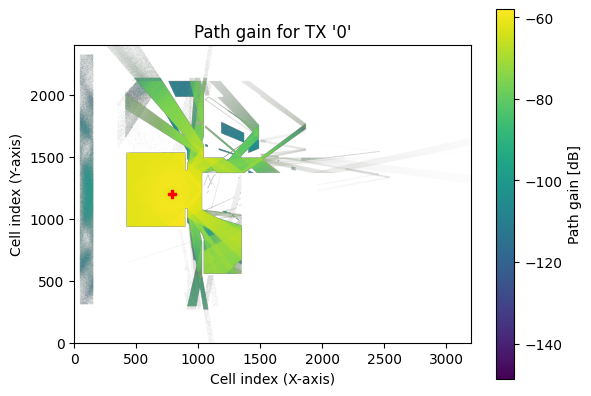

In [134]:
rmPlot = rm.show(tx=0)

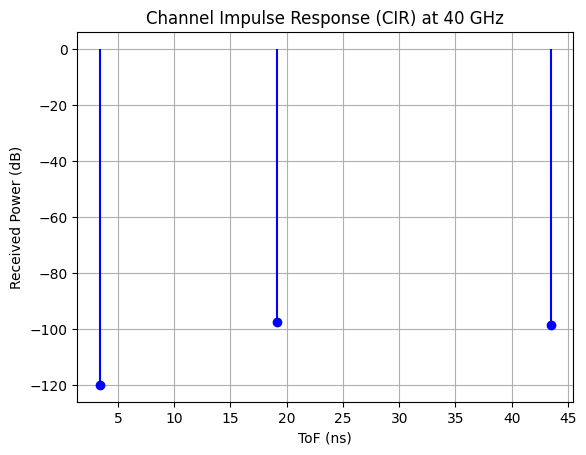

All captured paths: 16
Path 1, Delay = 3.39 ns, Power = -119.98 dB
Path 2, Delay = 19.13 ns, Power = -97.49 dB
Path 3, Delay = 43.46 ns, Power = -98.65 dB


In [136]:
# Extract CIR, complex amplitudes and time delay
a, tau = paths.cir()

amplitudesFix = a[0][0].numpy()
delaysFix = tau[0][0].numpy()

amplitudes = np.squeeze(amplitudesFix)
delays = np.squeeze(delaysFix)

validPaths = delays > 0
validDelays = delays[validPaths]
validAmplitudes = amplitudes[validPaths]

dBPower = 10*np.log10(np.abs(validAmplitudes)**2 + 1e-12)
delayInNs = validDelays*1e9

#Power Delay Profile
plt.figure()
plt.stem(delayInNs, dBPower, basefmt=" ", linefmt="blue", markerfmt="bo")
plt.title("Channel Impulse Response (CIR) at 40 GHz")
plt.xlabel("ToF (ns)")
plt.ylabel("Received Power (dB)")
plt.grid(True)
plt.show()

print(f"All captured paths: {len(validPaths)}")
for i in range(len(validDelays)):
    print(f"Path {i+1}, Delay = {delayInNs[i]:.2f} ns, Power = {dBPower[i]:.2f} dB")